# EXPLORATORIO

# Denoising utilizando Curvelets

El pipeline actual realiza un denoising 2D-1D basado en curvelets, donde se realiza la operación:

$$ W_{2D} \otimes W_{1D} $$

Para este caso, lo que habría que realizar es sustituir el operador espacial:

$$ C_{2D} \otimes W_{1D} $$

donde $C_{2D}$ es la curvelet 2D. El eje espectral se mantiene en wavelet 1D porque el perfil de línea es una singularidad 1D que la wavelet representa bien. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from curvelets_denoising import (
    CurveletTransform2D,
    ist_denoise_cube,
    reweighted_l1_denoise_cube,
)

## Ejemplo ejecutable

Backend de curvelet conectado: paquete `curvelets` (UDCT, Python puro).
A continuación se genera un cubo sintético `(n_chan, ny, nx)` con una
**estructura espacial curva** (un arco, donde las curvelets superan a las
wavelets separables) modulada por una **línea de emisión** gaussiana en el
eje espectral, se le añade ruido y se aplica el denoising 2D-1D
`C_2D ⊗ W_1D`.

Se usa `reweighted_l1_denoise_cube` (reweighted L1, Candès-Wakin-Boyd 2008),
el método recomendado: re-umbraliza los coeficientes de los datos con pesos
adaptativos derivados del modelo previo, aplica **positividad** y devuelve el
**mejor modelo** (menor varianza residual). Reduce el sesgo de encogimiento del
soft-threshold plano sobre la señal fuerte. Como referencia, también se muestra
el IST aditivo clásico (`ist_denoise_cube`).

In [38]:
rng = np.random.default_rng(0)

# --- cubo sintetico (n_chan, ny, nx) ---
n_chan, ny, nx = 48, 100, 100
yy, xx = np.mgrid[0:ny, 0:nx]

# estructura espacial curva (medio arco): caso donde la curvelet
# aproxima mejor que una wavelet 2D separable
cx, cy, R = nx / 2, ny / 2, 9.0
dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
arc = np.exp(-0.5 * ((dist - R) / 1.2) ** 2) * (yy < cy)

# perfil espectral: linea de emision gaussiana centrada en el canal 7
chans = np.arange(n_chan)
line = np.exp(-0.5 * ((chans - 7) / 1.5) ** 2)

clean = line[:, None, None] * arc[None, :, :]
clean /= clean.max()

sigma_noise = 0.3
noisy = clean + sigma_noise * rng.standard_normal(clean.shape)

# --- denoising 2D-1D  C_2D (x) W_1D  via REWEIGHTED L1 (recomendado) ---
den = reweighted_l1_denoise_cube(
    noisy,
    n_spec_scales=4,
    k_sigma=3.0,
    max_iter=15,
    ct_kwargs={"nbscales": 3, "nbangles_coarse": 3},
    verbose=True,
)

# --- referencia: IST aditivo clasico ---
den_ist = ist_denoise_cube(
    noisy,
    n_spec_scales=3,
    k_sigma=3.0,
    max_iter=15,
    ct_kwargs={"nbscales": 3, "nbangles_coarse": 3},
    verbose=False,
)


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


print()
print(f"RMSE ruidoso          vs limpio : {rmse(noisy, clean):.4f}")
print(f"RMSE reweighted L1    vs limpio : {rmse(den, clean):.4f}")
print(f"RMSE IST (referencia) vs limpio : {rmse(den_ist, clean):.4f}")

iter  0 | resid_var=8.248278e-02 | rel_change=nan
iter  1 | resid_var=8.283286e-02 | rel_change=4.24e-03
iter  2 | resid_var=8.281853e-02 | rel_change=1.73e-04
iter  3 | resid_var=8.280412e-02 | rel_change=1.74e-04
iter  4 | resid_var=8.279013e-02 | rel_change=1.69e-04
iter  5 | resid_var=8.278364e-02 | rel_change=7.84e-05
iter  6 | resid_var=8.277675e-02 | rel_change=8.33e-05
iter  7 | resid_var=8.277416e-02 | rel_change=3.13e-05
Plateau alcanzado en iter 7.
Mejor modelo: iter 0 (resid_var=8.248278e-02).

RMSE ruidoso          vs limpio : 0.3003
RMSE reweighted L1    vs limpio : 0.0656
RMSE IST (referencia) vs limpio : 0.1005


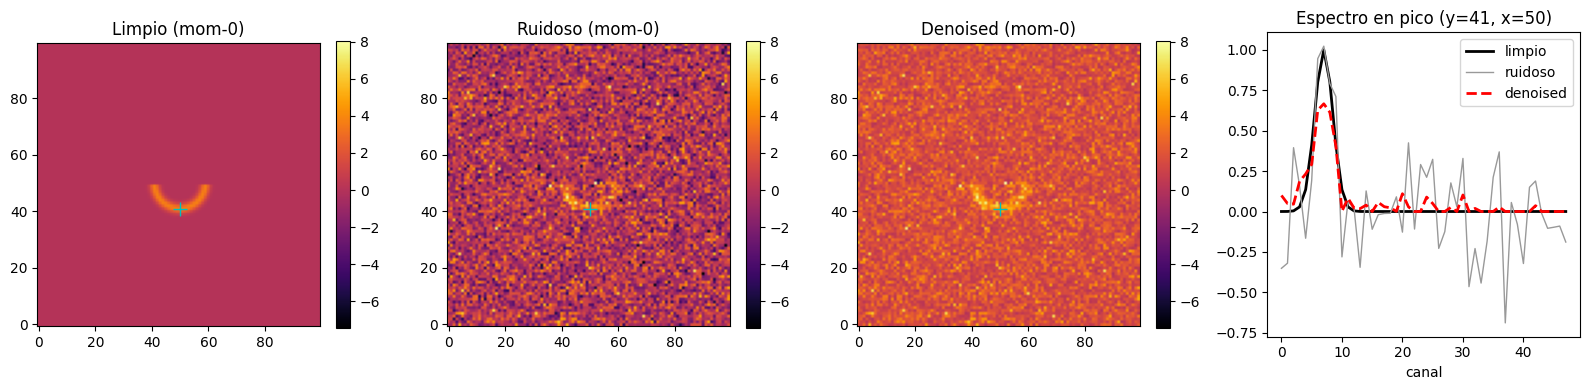

In [39]:
# mapas de momento-0 (integral espectral) y espectro en el pico
mom0 = lambda c: c.sum(axis=0)
py, px = np.unravel_index(np.argmax(clean.sum(axis=0)), (ny, nx))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmin = min(mom0(clean).min(), mom0(noisy).min(), mom0(den).min())
vmax = max(mom0(clean).max(), mom0(noisy).max(), mom0(den).max())
for ax, data, title in zip(
    axes[:3],
    [mom0(clean), mom0(noisy), mom0(den)],
    ["Limpio (mom-0)", "Ruidoso (mom-0)", "Denoised (mom-0)"],
):
    im = ax.imshow(data, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    ax.set_title(title)
    ax.plot(px, py, "c+", ms=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[3].plot(chans, clean[:, py, px], "k-", lw=2, label="limpio")
axes[3].plot(chans, noisy[:, py, px], "0.6", lw=1, label="ruidoso")
axes[3].plot(chans, den[:, py, px], "r--", lw=2, label="denoised")
axes[3].set_title(f"Espectro en pico (y={py}, x={px})")
axes[3].set_xlabel("canal")
axes[3].legend()

plt.tight_layout()
plt.show()

# Testing en Mock Cubes

In [2]:
import astropy.io.fits as fits
import os

DATA_DIR = '/Users/kuky/Documents/practica/WALDO/data'

CUBE_TYPE_DIR = 'mock_cubes'
CUBE_DIR = 'isolated_sub_AC5_N50_width1'
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub'

hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube = np.squeeze(hdu[0].data)
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

CUBE_NAME = 'isolated_sub_AC5_N50_width1_notnoisy_sub'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube_ref = np.squeeze(hdu[0].data)
cube_ref = np.nan_to_num(cube_ref, nan=0.0) # Se reemplazan los NaN por 0


In [3]:
# --- denoising 2D-1D  C_2D (x) W_1D  via REWEIGHTED L1 (recomendado) ---
den = reweighted_l1_denoise_cube(
    cube,
    n_spec_scales=3,
    k_sigma=3.0,
    max_iter=15,
    ct_kwargs={"nbscales": 6, "nbangles_coarse": 6},
    verbose=True,
    reference=cube_ref,   # (#3) selecciona el mejor modelo por RMSE vs limpio
    calibrate=True,       # (#2) calibra el ruido por propagacion 2D-1D
    # (#1) threshold_approx=True y protect_lowpass=True van por defecto
)

(*) Calibracion de ruido: sigma_global=1.1098e-04 | 373 subbandas calibradas.
iter  0 | resid_var=1.524724e-08 | rel_change=nan | rmse_ref=5.925727e-05
iter  1 | resid_var=1.527845e-08 | rel_change=2.05e-03 | rmse_ref=5.925727e-05
iter  2 | resid_var=1.527152e-08 | rel_change=4.54e-04 | rmse_ref=5.925727e-05
iter  3 | resid_var=1.526651e-08 | rel_change=3.28e-04 | rmse_ref=5.925727e-05
iter  4 | resid_var=1.526622e-08 | rel_change=1.93e-05 | rmse_ref=5.925727e-05
iter  5 | resid_var=1.525929e-08 | rel_change=4.54e-04 | rmse_ref=5.925727e-05
iter  6 | resid_var=1.526445e-08 | rel_change=3.39e-04 | rmse_ref=5.925727e-05
iter  7 | resid_var=1.525986e-08 | rel_change=3.01e-04 | rmse_ref=5.925727e-05
iter  8 | resid_var=1.526201e-08 | rel_change=1.41e-04 | rmse_ref=5.925727e-05
iter  9 | resid_var=1.526102e-08 | rel_change=6.49e-05 | rmse_ref=5.925727e-05
iter 10 | resid_var=1.526085e-08 | rel_change=1.11e-05 | rmse_ref=5.925727e-05
iter 11 | resid_var=1.526066e-08 | rel_change=1.28e-05 | r

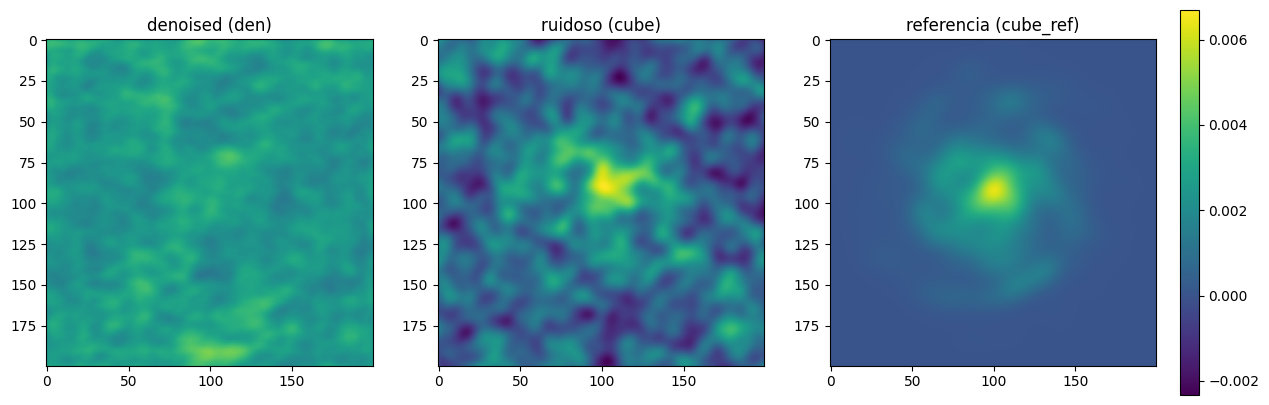

RMSE cube     vs cube_ref : 1.161957e-04
RMSE den      vs cube_ref : 5.925727e-05


In [5]:
mom0_den = np.sum(den, axis=0)
mom0_cube = np.sum(cube, axis=0)
mom0_ref = np.sum(cube_ref, axis=0)

# escala de color COMPARTIDA (comparacion justa entre paneles)
vmin = min(mom0_den.min(), mom0_cube.min(), mom0_ref.min())
vmax = max(mom0_den.max(), mom0_cube.max(), mom0_ref.max())

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(
    axs,
    [mom0_den, mom0_cube, mom0_ref],
    ["denoised (den)", "ruidoso (cube)", "referencia (cube_ref)"],
):
    im = ax.imshow(img, vmin=vmin, vmax=vmax)
    ax.set_title(title)
fig.colorbar(im, ax=axs, fraction=0.025, pad=0.02)
plt.show()

rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
print(f"RMSE cube     vs cube_ref : {rmse(cube, cube_ref):.6e}")
print(f"RMSE den      vs cube_ref : {rmse(den, cube_ref):.6e}")

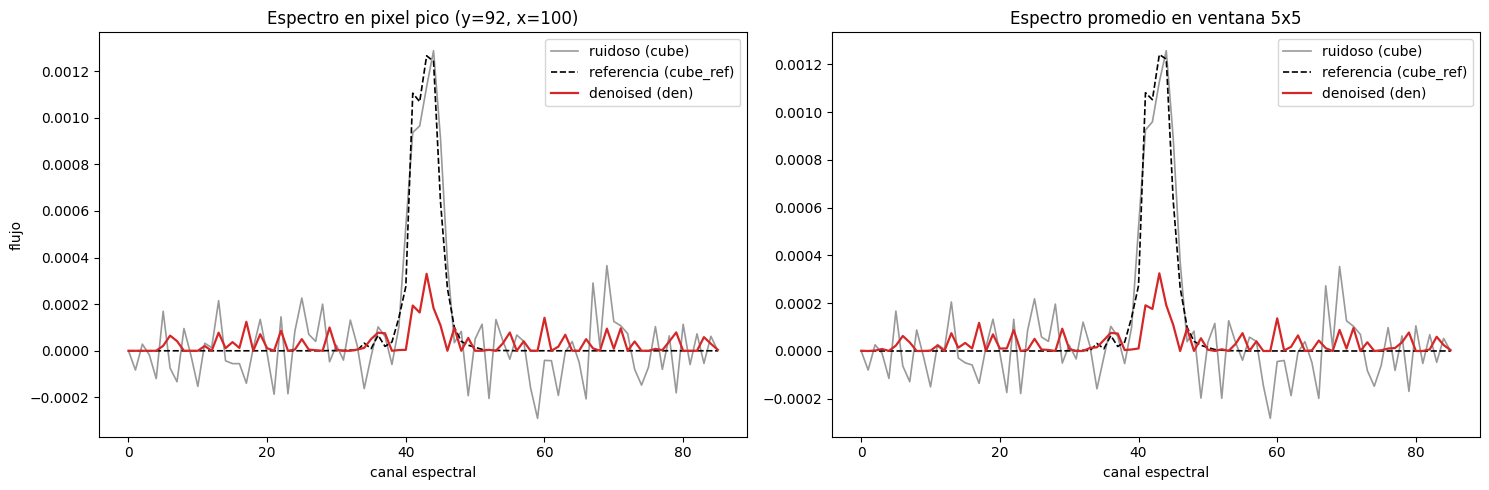

In [6]:
# Comparacion de curvas ESPECTRALES (perfil a lo largo del eje 0)
# Se elige el pixel mas brillante segun el flujo integrado del cubo de referencia.
flux_map = np.sum(cube_ref, axis=0)
y0, x0 = np.unravel_index(np.argmax(flux_map), flux_map.shape)

# region (ventana) alrededor del pixel pico para el espectro promedio
half = 2
ys = slice(max(0, y0 - half), y0 + half + 1)
xs = slice(max(0, x0 - half), x0 + half + 1)

spec_den_px = den[:, y0, x0]
spec_cube_px = cube[:, y0, x0]
spec_ref_px = cube_ref[:, y0, x0]

spec_den_avg = den[:, ys, xs].mean(axis=(1, 2))
spec_cube_avg = cube[:, ys, xs].mean(axis=(1, 2))
spec_ref_avg = cube_ref[:, ys, xs].mean(axis=(1, 2))

chan = np.arange(cube.shape[0])

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

axs[0].plot(chan, spec_cube_px, color="0.6", lw=1.2, label="ruidoso (cube)")
axs[0].plot(chan, spec_ref_px, "k--", lw=1.2, label="referencia (cube_ref)")
axs[0].plot(chan, spec_den_px, color="C3", lw=1.6, label="denoised (den)")
axs[0].set_title(f"Espectro en pixel pico (y={y0}, x={x0})")
axs[0].set_xlabel("canal espectral")
axs[0].set_ylabel("flujo")
axs[0].legend()

axs[1].plot(chan, spec_cube_avg, color="0.6", lw=1.2, label="ruidoso (cube)")
axs[1].plot(chan, spec_ref_avg, "k--", lw=1.2, label="referencia (cube_ref)")
axs[1].plot(chan, spec_den_avg, color="C3", lw=1.6, label="denoised (den)")
axs[1].set_title(f"Espectro promedio en ventana {2*half+1}x{2*half+1}")
axs[1].set_xlabel("canal espectral")
axs[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# --- Guardar el cubo denoised `den` como FITS para revisar en CARTA ---
# Se reutiliza el header (WCS) del cubo NOISY original y se respeta su
# forma de ejes (puede tener ejes degenerados, p. ej. Stokes) para que
# CARTA muestre los ejes espacial/espectral correctamente.

NOISY_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub'
src_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{NOISY_NAME}.fits')

with fits.open(src_path) as hdu_src:
    header = hdu_src[0].header.copy()
    orig_shape = hdu_src[0].data.shape

# `den` esta squeezed (n_chan, ny, nx); se devuelve a la forma original
# del FITS para mantener la consistencia con el header/WCS.
den_out = den.reshape(orig_shape).astype(np.float32)

# trazabilidad de como se genero el cubo
header['HISTORY'] = 'Denoised con reweighted_l1_denoise_cube (C_2D x W_1D)'
header['HISTORY'] = 'n_spec_scales=3, k_sigma=3.0, nbscales=6, nbangles_coarse=6'

OUT_DIR = os.path.join(DATA_DIR, 'denoised_cubes', CUBE_DIR)
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, f'{NOISY_NAME}_curvelet_denoised.fits')

fits.writeto(out_path, den_out, header=header, overwrite=True)
print(f'Cubo denoised guardado en:\n{out_path}')

Cubo denoised guardado en:
/Users/kuky/Documents/practica/WALDO/data/denoised_cubes/isolated_sub_AC5_N50_width1/isolated_sub_AC5_N50_width1_noisy_sub_curvelet_denoised.fits
